# Lab 03: From Frozen Features to Fine-Tuning

Using a pretrained ResNet18 on the EuroSAT satellite dataset and comparing two runs:

1. Feature extraction: freeze the whole backbone and only train a new last layer.
2. Fine-tuning: also unfreeze `layer4` and train it with a smaller learning rate.

Both runs use the same split, seed, augmentation and number of epochs.

In [1]:
import os
import time

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from torchvision.datasets.utils import download_and_extract_archive

SEED = 0
EPOCHS = 5
BATCH_SIZE = 32
TRAIN_PER_CLASS = 200
VAL_PER_CLASS = 50
HEAD_LR = 1e-3
BACKBONE_LR = 1e-4

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
os.makedirs("figures", exist_ok=True)

device: cpu


## 1. Dataset and transforms

The transforms are copied from the starter file.

In [2]:
# from lab03_starter.py
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

EuroSAT has 27,000 images in 10 classes. The full set is too slow to train on my laptop, so I take 200 train and 50 val images per class.

I load the folder twice, once with each transform, so the training images only get `train_transform` and the validation images only get `eval_transform`. The torchvision download link for EuroSAT is broken, so I download it from Hugging Face instead.

In [3]:
DATA_DIR = "data/2750"
EUROSAT_URL = ("https://huggingface.co/datasets/torchgeo/eurosat/resolve/"
               "c877bcd43f099cd0196738f714544e355477f3fd/EuroSAT.zip")

if not os.path.isdir(DATA_DIR):
    download_and_extract_archive(EUROSAT_URL, "data")

train_data = datasets.ImageFolder(DATA_DIR, transform=train_transform)
val_data = datasets.ImageFolder(DATA_DIR, transform=eval_transform)
classes = train_data.classes
num_classes = len(classes)

# pick the same train/val images for both runs
g = torch.Generator().manual_seed(SEED)
targets = torch.tensor(train_data.targets)
train_idx, val_idx = [], []
for c in range(num_classes):
    idx = (targets == c).nonzero().squeeze(1)
    idx = idx[torch.randperm(len(idx), generator=g)]
    train_idx += idx[:TRAIN_PER_CLASS].tolist()
    val_idx += idx[TRAIN_PER_CLASS:TRAIN_PER_CLASS + VAL_PER_CLASS].tolist()

train_set = Subset(train_data, train_idx)
val_set = Subset(val_data, val_idx)

print("classes:", classes)
print(f"training images: {len(train_set)}, validation images: {len(val_set)}")
print("overlap between train and val:", len(set(train_idx) & set(val_idx)))

classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
training images: 2000, validation images: 500
overlap between train and val: 0


### Checking the transforms

Running one image through each transform 5 times. The train ones should all be different and the eval ones should be the same.

train_transform passes identical: False
eval_transform passes identical:  True


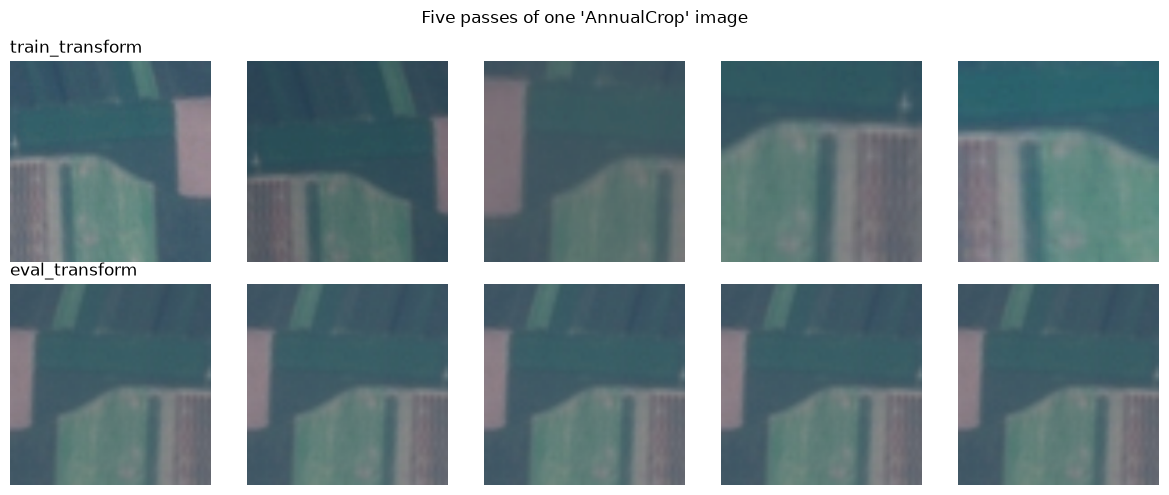

In [4]:
path, label = train_data.samples[train_idx[0]]
image = train_data.loader(path)

train_views = [train_transform(image) for _ in range(5)]
eval_views = [eval_transform(image) for _ in range(5)]

print("train_transform passes identical:", all(torch.equal(train_views[0], v) for v in train_views[1:]))
print("eval_transform passes identical: ", all(torch.equal(eval_views[0], v) for v in eval_views[1:]))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    for row, views in enumerate([train_views, eval_views]):
        img = (views[i] * std + mean).clamp(0, 1).permute(1, 2, 0)
        axes[row, i].imshow(img)
        axes[row, i].axis("off")
axes[0, 0].set_title("train_transform", loc="left")
axes[1, 0].set_title("eval_transform", loc="left")
fig.suptitle(f"Five passes of one '{classes[label]}' image")
plt.tight_layout()
plt.savefig("figures/transform_check.png", dpi=150)
plt.show()

The train versions are all different crops, some flipped, with slightly different colours. The eval versions are exactly the same every time.

## 2. Feature extraction

`build_model` loads ResNet18 with ImageNet weights, freezes everything, then swaps in a new `fc` layer for 10 classes. The new layer is the only thing that can train. The seed is set inside `build_model` and the loader so both runs start the same way.

In [5]:
def build_model():
    torch.manual_seed(SEED)
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def make_train_loader():
    g = torch.Generator().manual_seed(SEED)
    return DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, generator=g)


val_loader = DataLoader(val_set, batch_size=64, shuffle=False)


def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate(model):
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            preds = model(x.to(device)).argmax(1)
            correct += (preds == y.to(device)).sum().item()
    return correct / len(val_set)


def train(model, optimizer, set_mode):
    loss_fn = nn.CrossEntropyLoss()
    loader = make_train_loader()
    torch.manual_seed(SEED)  # same random crops and flips in both runs
    history = {"loss": [], "val_acc": []}
    train_time = 0.0

    for epoch in range(EPOCHS):
        set_mode(model)
        start = time.time()
        total_loss = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y)
        train_time += time.time() - start

        history["loss"].append(total_loss / len(train_set))
        history["val_acc"].append(evaluate(model))
        print(f"epoch {epoch + 1}: loss = {history['loss'][-1]:.4f}, val acc = {history['val_acc'][-1]:.3f}")

    history["train_time"] = train_time
    history["trainable"] = count_trainable(model)
    return history


results = {}

The whole model stays in `eval()` here. If the frozen backbone was in `train()`, its BatchNorm layers would still update their running mean and variance from my data, even with `requires_grad=False`, so the "frozen" features would slowly change.

In [6]:
def frozen_mode(model):
    model.eval()


model = build_model()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=HEAD_LR)
print(f"trainable params: {count_trainable(model)}")
results["Feature extraction"] = train(model, optimizer, frozen_mode)
print(f"train time: {results['Feature extraction']['train_time']:.1f}s")

trainable params: 5130


epoch 1: loss = 1.5422, val acc = 0.816


epoch 2: loss = 0.8602, val acc = 0.868


epoch 3: loss = 0.6627, val acc = 0.872


epoch 4: loss = 0.6286, val acc = 0.876


epoch 5: loss = 0.5333, val acc = 0.892
train time: 282.0s


Got 0.892 val accuracy with only 5,130 trainable parameters. It was already at 0.816 after one epoch, so the ImageNet features help even on satellite images. The loss was still 0.53 at the end.

## 3. Fine-tuning

Same starting model, but `layer4` is unfrozen. One optimizer with two parameter groups: `layer4` gets lr 1e-4 and the head gets 1e-3, the same as before. Only `layer4` goes in `train()` mode, the frozen layers stay in `eval()`.

In [7]:
def fine_tune_mode(model):
    model.eval()
    model.layer4.train()


model = build_model()
for p in model.layer4.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": BACKBONE_LR},
    {"params": model.fc.parameters(), "lr": HEAD_LR},
])
print(f"trainable params: {count_trainable(model)}")
results["Fine-tuning"] = train(model, optimizer, fine_tune_mode)
print(f"train time: {results['Fine-tuning']['train_time']:.1f}s")

trainable params: 8398858


epoch 1: loss = 0.8222, val acc = 0.904


epoch 2: loss = 0.4415, val acc = 0.904


epoch 3: loss = 0.3208, val acc = 0.930


epoch 4: loss = 0.3435, val acc = 0.932


epoch 5: loss = 0.2776, val acc = 0.944
train time: 354.7s


Got 0.944 val accuracy, 5.2 points higher than feature extraction. After one epoch it was already better than the frozen run after five. It took about 26% longer to train since 8.4 million parameters are being updated instead of 5 thousand.

## 4. Comparison

Run                  | val accuracy | train time | trainable params
--------------------------------------------------------------------
Feature extraction   |        0.892 |     282.0s |            5,130
Fine-tuning          |        0.944 |     354.7s |        8,398,858


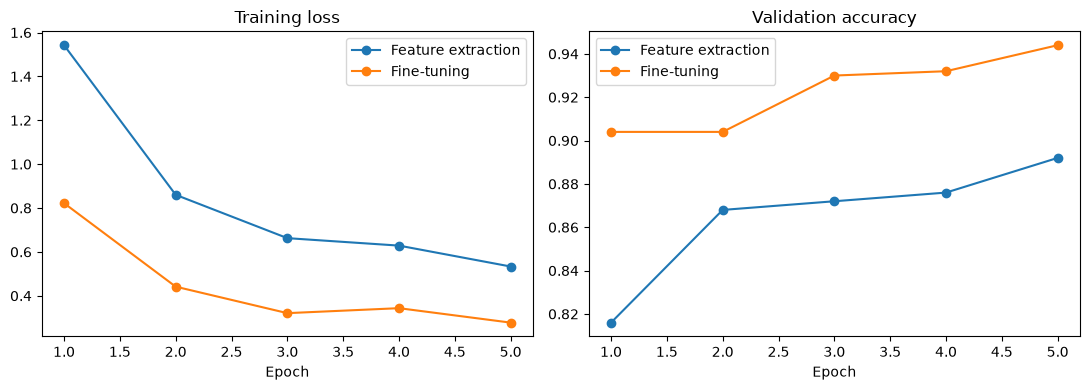

In [8]:
print(f"{'Run':<20} | {'val accuracy':>12} | {'train time':>10} | {'trainable params':>16}")
print("-" * 68)
for name, h in results.items():
    print(f"{name:<20} | {h['val_acc'][-1]:>12.3f} | {h['train_time']:>9.1f}s | {h['trainable']:>16,}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, h in results.items():
    epochs = range(1, EPOCHS + 1)
    axes[0].plot(epochs, h["loss"], marker="o", label=name)
    axes[1].plot(epochs, h["val_acc"], marker="o", label=name)
axes[0].set_title("Training loss")
axes[1].set_title("Validation accuracy")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.savefig("figures/comparison.png", dpi=150)
plt.show()

## Conclusion

Fine-tuning won, 0.944 vs 0.892, and the only difference between the runs was whether `layer4` could train.

With everything frozen, the head can only work with the features ResNet18 learned for ImageNet photos. EuroSAT is top-down satellite images, and classes like the different crop types, or highways and rivers, need features ImageNet never had to learn. Unfreezing `layer4` let those features change to fit this dataset, which the head alone can't do. That's why the loss got down to 0.28 instead of 0.53.

The smaller learning rate on `layer4` is so it only adjusts the pretrained weights a bit while the new head learns from scratch.

Feature extraction was still pretty good for how little it trains. On a dataset closer to ImageNet it could tie or win.